Based on:

Friedemann Zenke, Tim P. Vogels; The Remarkable Robustness of Surrogate Gradient Learning for Instilling Complex Function in Spiking Neural Networks. Neural Comput 2021; 33 (4): 899-925. doi: https://doi.org/10.1162/neco_a_01367

In [1]:
%matplotlib widget
import torch

from thesis_code.datasets import get_SHD_dataloader
from thesis_code.networks import train, test, models
from thesis_code.plotting import plot_performance, plot_gradients, InteractiveSpikePlot

In [2]:
torch.manual_seed(42)
dtype = torch.float
device = torch.device("cuda") if torch.cuda.is_available() else torch.device("mps") if torch.backends.mps.is_available() else torch.device("cpu")

Timesteps are in milliseconds

In [3]:
dt = 0.001

In [4]:
SHD_trainloader, input_dim, classes = get_SHD_dataloader(
    batch_size=128,
    time_window=1000,
    train=True,
    shuffle=True,
    drop_last=True,
    re_download=False,
)

SHD_testloader, _, _ = get_SHD_dataloader(
    batch_size=128,
    time_window=1000,
    train=False,
    shuffle=True,
    drop_last=True,
    re_download=False,
)

Test Accuracy before training is: 0.03952205882352941


Epoch 0:   0%|          | 0/63 [00:00<?, ?it/s]

Epoch 0, Iteration 0 — Loss: 3.75, Acc: 3.91%
Epoch 0, Iteration 25 — Loss: 2.63, Acc: 17.19%
Epoch 0, Iteration 50 — Loss: 1.92, Acc: 20.31%


Epoch 1:   0%|          | 0/63 [00:00<?, ?it/s]

Epoch 1, Iteration 0 — Loss: 2.04, Acc: 41.41%
Epoch 1, Iteration 25 — Loss: 1.79, Acc: 39.06%
Epoch 1, Iteration 50 — Loss: 1.66, Acc: 41.41%


...

Epoch 47, Iteration 0 — Loss: 0.21, Acc: 99.22%
Epoch 47, Iteration 25 — Loss: 0.23, Acc: 98.44%
Epoch 47, Iteration 50 — Loss: 0.44, Acc: 88.28%


Epoch 48:   0%|          | 0/63 [00:00<?, ?it/s]

Epoch 48, Iteration 0 — Loss: 0.25, Acc: 97.66%
Epoch 48, Iteration 25 — Loss: 0.26, Acc: 97.66%
Epoch 48, Iteration 50 — Loss: 0.28, Acc: 96.09%


Epoch 49:   0%|          | 0/63 [00:00<?, ?it/s]

Epoch 49, Iteration 0 — Loss: 0.27, Acc: 98.44%
Epoch 49, Iteration 25 — Loss: 0.25, Acc: 98.44%
Epoch 49, Iteration 50 — Loss: 0.25, Acc: 97.66%
Test Accuracy after training is: 0.8625919117647058


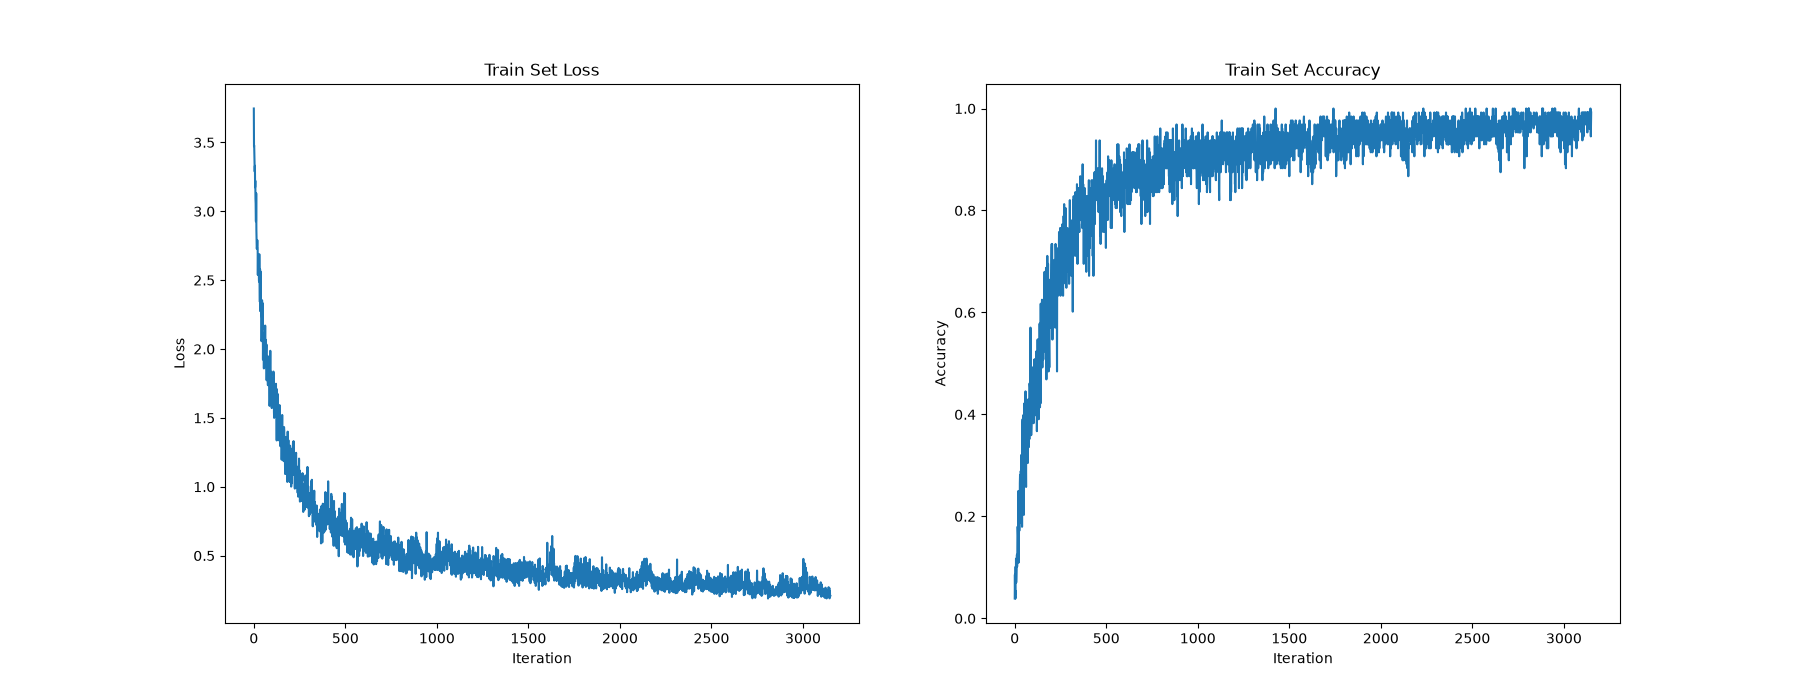

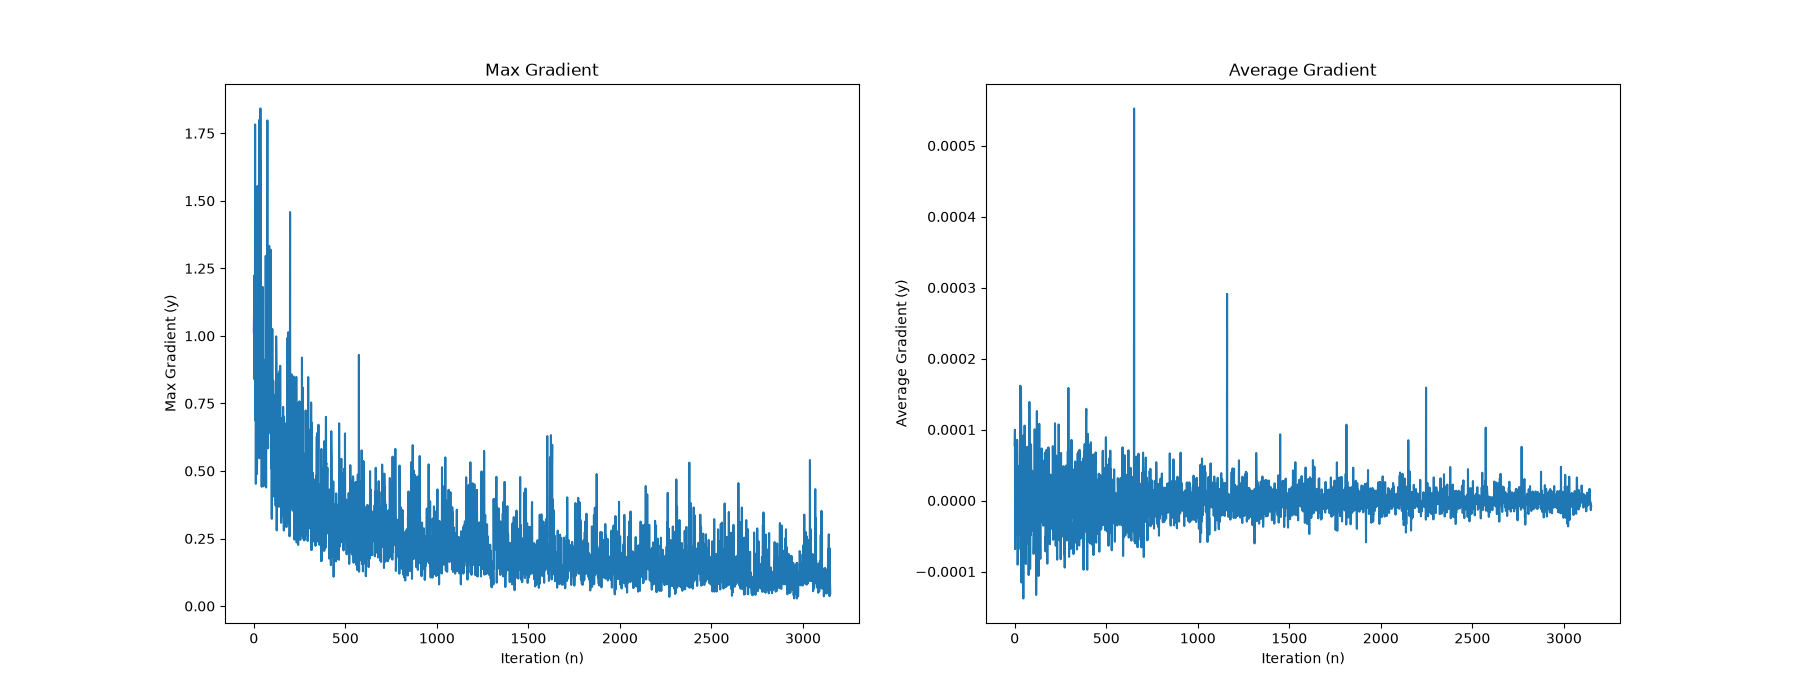

In [5]:
import torch.nn as nn
from torch.utils.data import DataLoader
from tqdm.auto import tqdm
import numpy as np
import torch.nn.functional as F
from snntorch import surrogate
from typing import Callable

from matplotlib import pyplot as plt

from thesis_code.training import get_compute_loss_reg_fn
from thesis_code.custom_objects.building_blocks import sample_heterogeneous_decays_normal, tau_to_beta

def compute_loss(mem_rec: torch.Tensor, targets: torch.Tensor) -> torch.Tensor:
    probs = F.softmax(mem_rec, dim=-1)
    log_probs = torch.log(probs.mean(dim=0) + 1e-8) # to avoid log(0)
    return F.nll_loss(log_probs, targets)

def measure_accuracy(mem_rec, targets):
    _, idx = mem_rec.sum(dim=0).max(1)
    return np.mean((targets == idx).detach().cpu().numpy())

def test(net: nn.Module, device: torch.device, testloader: DataLoader, max_iters: int = None) -> float:
    with torch.no_grad():
        acc = 0
        net.eval()

        for i, (data, targets) in enumerate(testloader):
            data, targets = data.to(device), targets.to(device).long()
            data = data.squeeze(2)
            
            spk_rec, mem_rec, hidden_spks = net(data)
            acc += measure_accuracy(mem_rec, targets)
            if max_iters is not None and i == max_iters:
                break

    return acc / len(testloader)

def record_grads(net: nn.Module) -> tuple[list, list]:
    grads = {name: p.grad.detach().clone()
        for name, p in net.named_parameters() if p.grad is not None}
    if len(grads) > 0:
        flat_grads = torch.cat([t.flatten() for t in grads.values()])
        return flat_grads.max(dim=0).values.cpu().numpy(), flat_grads.mean(dim=0).cpu().numpy()
    return 0, 0

def train(net: nn.Module, device: torch.device, trainloader: DataLoader, loss_fn: Callable, lr: float = 1e-3, n_epochs: int = 1, max_iters: int = None) -> tuple[nn.Module, list, list]:
    optimizer = torch.optim.Adam(net.parameters(), lr=lr, eps=1e-6, betas=(0.9, 0.99))

    loss_hist, acc_hist, spike_hist = [], [], []
    net.train()
    max_grad_rec = []
    avg_grad_rec = []

    for epoch in range(n_epochs):
        progress_bar = tqdm(enumerate(trainloader), total=len(trainloader), desc=f"Epoch {epoch}")
        for i, (data, targets) in progress_bar:
            data, targets = data.to(device), targets.to(device).long()
            data = data.squeeze(2)

            spk_outs, mem_outs, hidden_spks = net(data)
            loss_val = loss_fn(mem_outs, targets, hidden_spks)

            optimizer.zero_grad()
            loss_val.backward()

            # torch.nn.utils.clip_grad_value_(net.parameters(), clip_value=1e6)

            max_grad, avg_grad = record_grads(net)
            max_grad_rec.append(max_grad)
            avg_grad_rec.append(avg_grad)

            optimizer.step()

            loss_hist.append(loss_val.item())

            acc = measure_accuracy(mem_outs, targets)
            acc_hist.append(acc)

            progress_bar.set_postfix(loss=f"{loss_val.item():.2f}", acc=f"{acc * 100:.2f}%")

            if i % 25 == 0:
                tqdm.write(f"Epoch {epoch}, Iteration {i} — Loss: {loss_val.item():.2f}, Acc: {acc*100:.2f}%")

            if max_iters is not None and i == max_iters:
                break

    return net, loss_hist, acc_hist, spike_hist, max_grad_rec, avg_grad_rec


ns_hidden=[256, 256]
layers = [input_dim] + ns_hidden

net = models.StandardSRNN(
    forward_matrices=[torch.ones(n_in, n_out) for n_in, n_out in zip(layers[:-1], layers[1:])],
    recurrent_matrices=[torch.ones(n, n) for n in ns_hidden],
    betas=[sample_heterogeneous_decays_normal(dt, n, tau_mean=10 * dt, tau_std=1 * dt, device=device) for n in ns_hidden],
    beta_out=tau_to_beta(dt, 20 * dt),
    n_classes=len(classes),
    spike_grad=surrogate.fast_sigmoid(slope=25),
).to(device)

# net = models.SynapticSRNN(
#     forward_matrices=[torch.ones(n_in, n_out) for n_in, n_out in zip(layers[:-1], layers[1:])],
#     recurrent_matrices=[torch.ones(n, n) for n in ns_hidden],
#     alphas=[sample_heterogeneous_decays_normal(dt, n, tau_mean=5 * dt, tau_std=1 * dt, device=device) for n in ns_hidden],
#     betas=[sample_heterogeneous_decays_normal(dt, n, tau_mean=10 * dt, tau_std=2 * dt, device=device) for n in ns_hidden],
#     beta_out=tau_to_beta(dt, 20 * dt),
#     n_classes=len(classes),
#     spike_grad=surrogate.fast_sigmoid(slope=25),
# ).to(device)

compute_loss_reg = get_compute_loss_reg_fn(
    lam_lower=100.0,
    v_lower=1e-2,               # min n spikes
    lam_uppers=[0.5, 0.5],
    v_uppers=[50, 50],          # max n spikes per layer
    L=2,
)

accuracy = test(
    net=net,
    device=device,
    testloader=SHD_testloader,
    max_iters=None,
)
print(f"Test Accuracy before training is: {accuracy}")

net, loss_hist, acc_hist, spike_hist, max_grad_rec, avg_grad_rec = train(
    net=net,
    device=device,
    trainloader=SHD_trainloader,
    loss_fn=lambda mem_outs, targets, hidden_spks: compute_loss(mem_outs, targets) + compute_loss_reg(hidden_spks),
    lr=1e-3,
    n_epochs=50,
    max_iters=None,
)
plot_performance(loss_hist, acc_hist)
plot_gradients(max_grad_rec, avg_grad_rec)

accuracy = test(
    net=net,
    device=device,
    testloader=SHD_testloader,
    max_iters=None,
)
print(f"Test Accuracy after training is: {accuracy}")

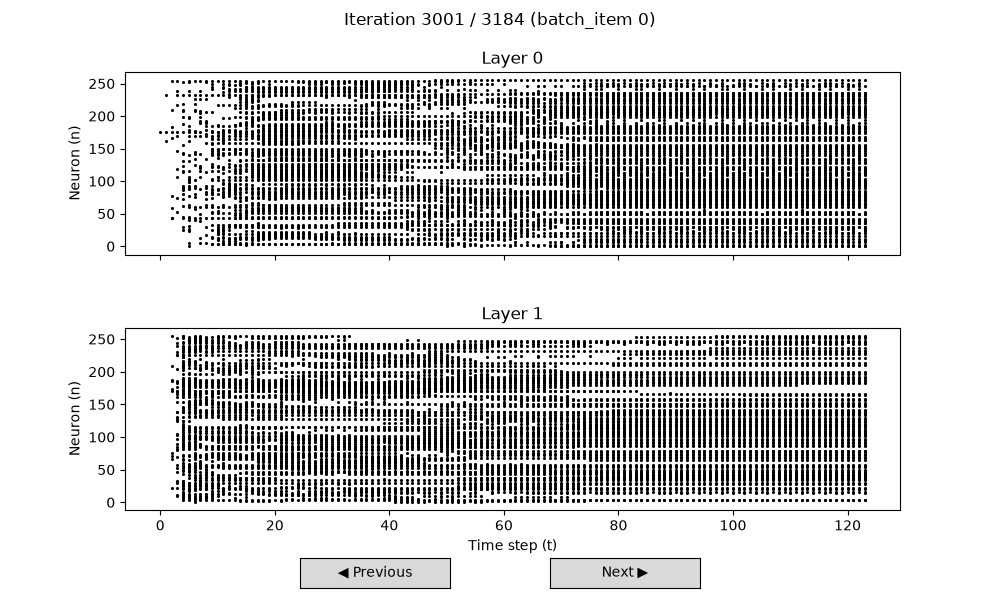

In [7]:
isp = InteractiveSpikePlot(
    recorder=net.get_recorder(), 
    iteration_i_start=3000, 
    batch_item_i=0,
)
isp.draw()
plt.show()

Test Accuracy before training is: 0.04917279411764706


Epoch 0:   0%|          | 0/63 [00:00<?, ?it/s]

Epoch 0, Iteration 0 — Loss: 12.21, Acc: 5.47%
Epoch 0, Iteration 25 — Loss: 3.32, Acc: 8.59%
Epoch 0, Iteration 50 — Loss: 2.77, Acc: 11.72%


Epoch 1:   0%|          | 0/63 [00:00<?, ?it/s]

Epoch 1, Iteration 0 — Loss: 2.46, Acc: 26.56%
Epoch 1, Iteration 25 — Loss: 2.70, Acc: 13.28%
Epoch 1, Iteration 50 — Loss: 2.37, Acc: 20.31%


...

Epoch 47, Iteration 0 — Loss: 0.52, Acc: 85.16%
Epoch 47, Iteration 25 — Loss: 0.60, Acc: 91.41%
Epoch 47, Iteration 50 — Loss: 0.54, Acc: 85.94%


Epoch 48:   0%|          | 0/63 [00:00<?, ?it/s]

Epoch 48, Iteration 0 — Loss: 0.52, Acc: 89.06%
Epoch 48, Iteration 25 — Loss: 0.50, Acc: 89.06%
Epoch 48, Iteration 50 — Loss: 0.54, Acc: 84.38%


Epoch 49:   0%|          | 0/63 [00:00<?, ?it/s]

Epoch 49, Iteration 0 — Loss: 0.50, Acc: 89.06%
Epoch 49, Iteration 25 — Loss: 0.55, Acc: 86.72%
Epoch 49, Iteration 50 — Loss: 0.66, Acc: 83.59%
Test Accuracy after training is: 0.7311580882352942


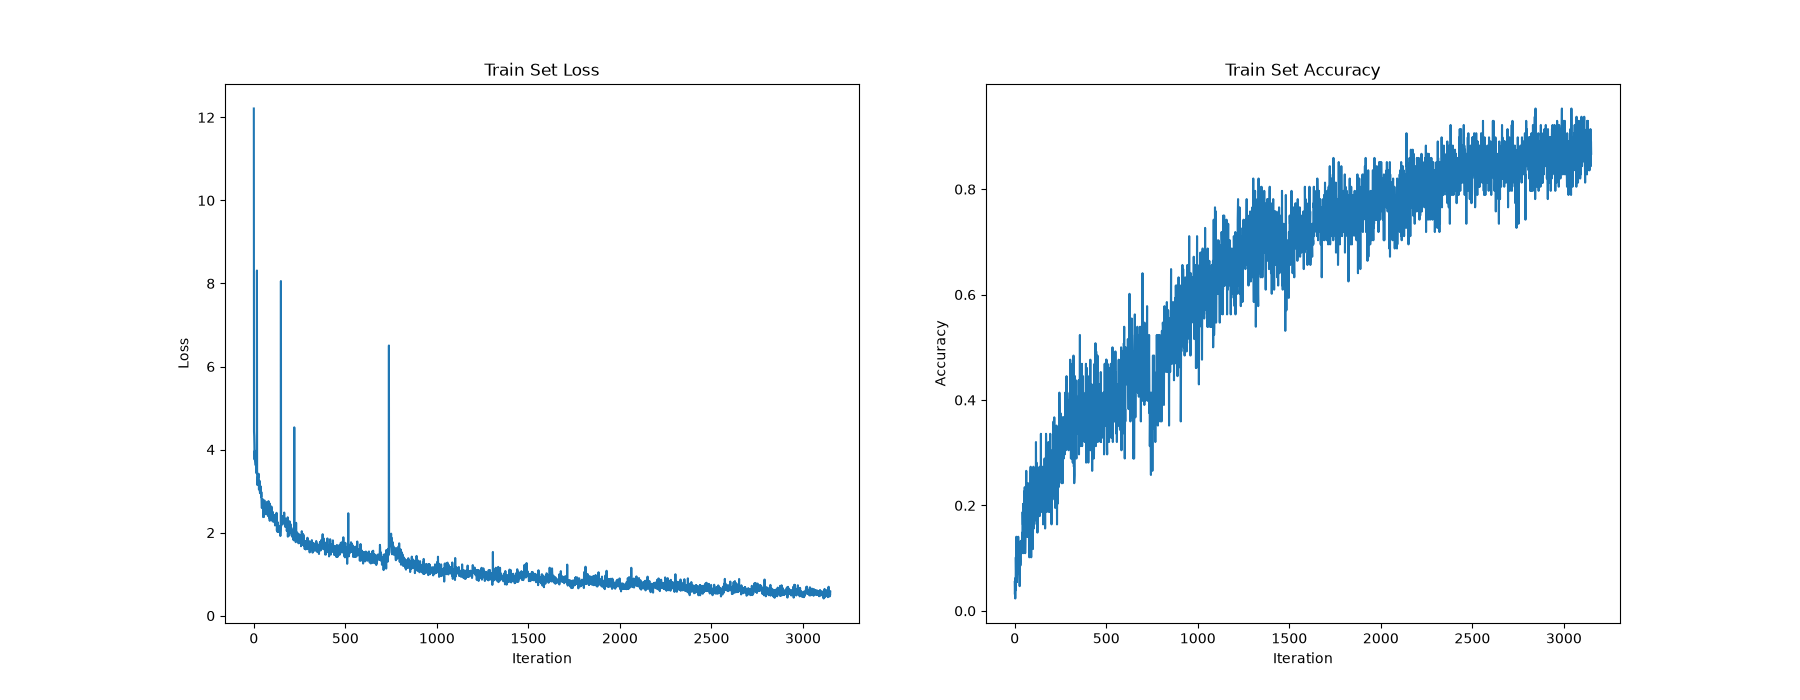

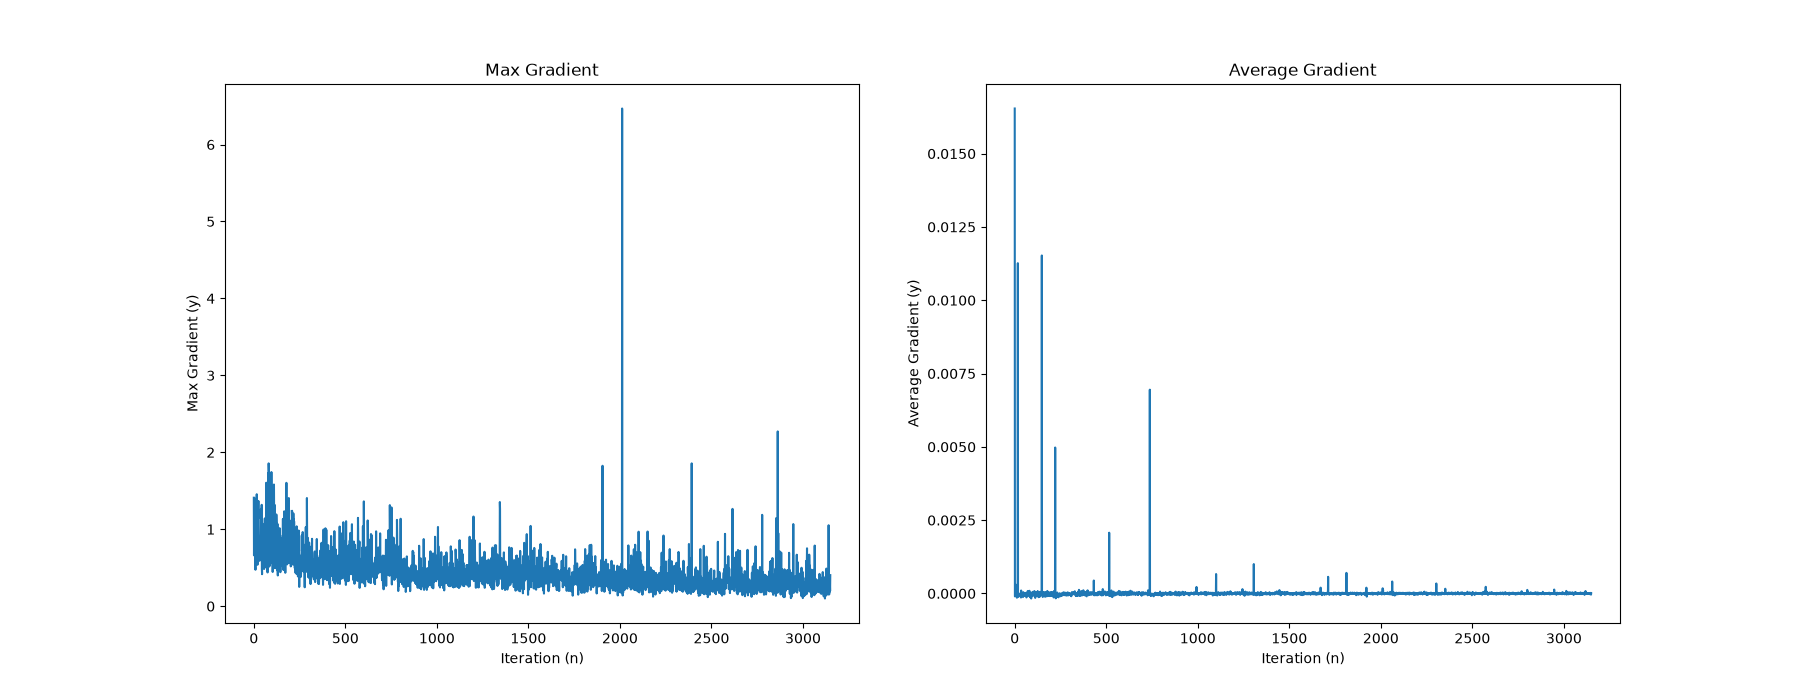

In [5]:
import torch.nn as nn
from torch.utils.data import DataLoader
from tqdm.auto import tqdm
import numpy as np
import torch.nn.functional as F
from snntorch import surrogate
from typing import Callable

from matplotlib import pyplot as plt

from thesis_code.training import get_compute_loss_reg_fn
from thesis_code.custom_objects.building_blocks import sample_heterogeneous_decays_normal, tau_to_beta

def compute_loss(mem_rec: torch.Tensor, targets: torch.Tensor) -> torch.Tensor:
    probs = F.softmax(mem_rec, dim=-1)
    log_probs = torch.log(probs.mean(dim=0) + 1e-8) # to avoid log(0)
    return F.nll_loss(log_probs, targets)

def measure_accuracy(mem_rec, targets):
    _, idx = mem_rec.sum(dim=0).max(1)
    return np.mean((targets == idx).detach().cpu().numpy())

def test(net: nn.Module, device: torch.device, testloader: DataLoader, max_iters: int = None) -> float:
    with torch.no_grad():
        acc = 0
        net.eval()

        for i, (data, targets) in enumerate(testloader):
            data, targets = data.to(device), targets.to(device).long()
            data = data.squeeze(2)
            
            spk_rec, mem_rec, hidden_spks = net(data)
            acc += measure_accuracy(mem_rec, targets)
            if max_iters is not None and i == max_iters:
                break

    return acc / len(testloader)

def record_grads(net: nn.Module) -> tuple[list, list]:
    grads = {name: p.grad.detach().clone()
        for name, p in net.named_parameters() if p.grad is not None}
    if len(grads) > 0:
        flat_grads = torch.cat([t.flatten() for t in grads.values()])
        return flat_grads.max(dim=0).values.cpu().numpy(), flat_grads.mean(dim=0).cpu().numpy()
    return 0, 0

def train(net: nn.Module, device: torch.device, trainloader: DataLoader, loss_fn: Callable, lr: float = 1e-3, n_epochs: int = 1, max_iters: int = None) -> tuple[nn.Module, list, list]:
    optimizer = torch.optim.Adam(net.parameters(), lr=lr, eps=1e-6, betas=(0.9, 0.99))

    loss_hist, acc_hist, spike_hist = [], [], []
    net.train()
    max_grad_rec = []
    avg_grad_rec = []

    for epoch in range(n_epochs):
        progress_bar = tqdm(enumerate(trainloader), total=len(trainloader), desc=f"Epoch {epoch}")
        for i, (data, targets) in progress_bar:
            data, targets = data.to(device), targets.to(device).long()
            data = data.squeeze(2)

            spk_outs, mem_outs, hidden_spks = net(data)
            loss_val = loss_fn(mem_outs, targets, hidden_spks)

            optimizer.zero_grad()
            loss_val.backward()

            # torch.nn.utils.clip_grad_value_(net.parameters(), clip_value=1e6)

            max_grad, avg_grad = record_grads(net)
            max_grad_rec.append(max_grad)
            avg_grad_rec.append(avg_grad)

            optimizer.step()

            loss_hist.append(loss_val.item())

            acc = measure_accuracy(mem_outs, targets)
            acc_hist.append(acc)

            progress_bar.set_postfix(loss=f"{loss_val.item():.2f}", acc=f"{acc * 100:.2f}%")

            if i % 25 == 0:
                tqdm.write(f"Epoch {epoch}, Iteration {i} — Loss: {loss_val.item():.2f}, Acc: {acc*100:.2f}%")

            if max_iters is not None and i == max_iters:
                break

    return net, loss_hist, acc_hist, spike_hist, max_grad_rec, avg_grad_rec


ns_hidden=[256, 256]
layers = [input_dim] + ns_hidden

# net = models.StandardSRNN(
#     forward_matrices=[torch.ones(n_in, n_out) for n_in, n_out in zip(layers[:-1], layers[1:])],
#     recurrent_matrices=[torch.ones(n, n) for n in ns_hidden],
#     betas=[sample_heterogeneous_decays_normal(dt, n, tau_mean=10 * dt, tau_std=1 * dt, device=device) for n in ns_hidden],
#     beta_out=tau_to_beta(dt, 20 * dt),
#     n_classes=len(classes),
#     spike_grad=surrogate.fast_sigmoid(slope=25),
# ).to(device)

net = models.SynapticSRNN(
    forward_matrices=[torch.ones(n_in, n_out) for n_in, n_out in zip(layers[:-1], layers[1:])],
    recurrent_matrices=[torch.ones(n, n) for n in ns_hidden],
    alphas=[sample_heterogeneous_decays_normal(dt, n, tau_mean=5 * dt, tau_std=1 * dt, device=device) for n in ns_hidden],
    betas=[sample_heterogeneous_decays_normal(dt, n, tau_mean=10 * dt, tau_std=2 * dt, device=device) for n in ns_hidden],
    beta_out=tau_to_beta(dt, 20 * dt),
    n_classes=len(classes),
    spike_grad=surrogate.fast_sigmoid(slope=25),
).to(device)

compute_loss_reg = get_compute_loss_reg_fn(
    lam_lower=100.0,
    v_lower=1e-2,               # min n spikes
    lam_uppers=[0.5, 0.5],
    v_uppers=[50, 50],          # max n spikes per layer
    L=2,
)

accuracy = test(
    net=net,
    device=device,
    testloader=SHD_testloader,
    max_iters=None,
)
print(f"Test Accuracy before training is: {accuracy}")

net, loss_hist, acc_hist, spike_hist, max_grad_rec, avg_grad_rec = train(
    net=net,
    device=device,
    trainloader=SHD_trainloader,
    loss_fn=lambda mem_outs, targets, hidden_spks: compute_loss(mem_outs, targets) + compute_loss_reg(hidden_spks),
    lr=1e-3,
    n_epochs=50,
    max_iters=None,
)
plot_performance(loss_hist, acc_hist)
plot_gradients(max_grad_rec, avg_grad_rec)

accuracy = test(
    net=net,
    device=device,
    testloader=SHD_testloader,
    max_iters=None,
)
print(f"Test Accuracy after training is: {accuracy}")